 
**Models:** Logistic Regression · SVM · Decision Tree · Random Forest · MLP  
**Steps:** Load → Preprocess → Train → Evaluate → Visualize


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

from rich.console import Console
from rich.table import Table

console = Console()
print("Libraries loaded successfully!")
print(os.getcwd())


Libraries loaded successfully!
c:\Users\youse


##  Load Data

In [13]:
def load_data():
    try:
        train_df = pd.read_csv("trainY.csv")
        test_df  = pd.read_csv("testY.csv")

        print(f"train.csv loaded: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
        print(f"test.csv  loaded: {test_df.shape[0]} rows, {test_df.shape[1]} columns")

        return train_df, test_df

    except FileNotFoundError as e:
        print(f"Error: {e}")
        print("Make sure train.csv and test.csv are in the same folder as this notebook.")
        raise

train_df, test_df = load_data()
train_df.head()
print("##"*50)
print(train_df.columns)

train.csv loaded: 103904 rows, 25 columns
test.csv  loaded: 25976 rows, 25 columns
####################################################################################################
Index(['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='str')


## Preprocessing

In [ ]:
TARGET_COLUMN = "satisfaction"

def preprocess(train_df, test_df, target_column):

    combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)

    for col in combined.columns:

   
     if combined[col].dtype == "object":

        temp_col = pd.to_numeric(combined[col], errors="coerce")

       
        if temp_col.notna().all():
            combined[col] = temp_col

   
    if pd.api.types.is_numeric_dtype(combined[col]):
        combined[col].fillna(combined[col].median(), inplace=True)

    else:
        combined[col].fillna(combined[col].mode()[0], inplace=True)

    le = LabelEncoder()

    for col in combined.select_dtypes(include="object").columns:
        combined[col] = le.fit_transform(combined[col].astype(str))

    train_clean = combined.iloc[:len(train_df)]

    X = train_clean.drop(columns=[target_column])
    y = train_clean[target_column]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, y, scaler


X, y, scaler = preprocess(train_df, test_df, TARGET_COLUMN)

## Train / Validation Split

In [19]:
def split_data(X, y, test_size=0.2):
    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )
    X_train = np.nan_to_num(X_train)
    X_val = np.nan_to_num(X_val) 
    print(f"Training samples:   {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    return X_train, X_val, y_train, y_val

X_train, X_val, y_train, y_val = split_data(X, y)


Training samples:   83123
Validation samples: 20781


##  Define Models

In [20]:
def get_models():
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "SVM":                 SVC(kernel="rbf", random_state=42),
        "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=42),
        "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
        "MLP Classifier":      MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42),
    }
    return models

models = get_models()
print(f"{len(models)} models ready:", list(models.keys()))


5 models ready: ['Logistic Regression', 'SVM', 'Decision Tree', 'Random Forest', 'MLP Classifier']


##  Train & Evaluate

In [21]:
def train_and_evaluate(models, X_train, X_val, y_train, y_val):
    results = {}
    reports = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        acc    = accuracy_score(y_val, y_pred)
        report = classification_report(y_val, y_pred, zero_division=0)
        cm     = confusion_matrix(y_val, y_pred)

        results[name] = acc
        reports[name] = {"report": report, "cm": cm, "y_pred": y_pred}

        print(f"  {name:<22} Accuracy: {acc:.4f}")

    return results, reports

print("Training models...\n")
results, reports = train_and_evaluate(models, X_train, X_val, y_train, y_val)


Training models...

  Logistic Regression    Accuracy: 0.8774
  SVM                    Accuracy: 0.9557
  Decision Tree          Accuracy: 0.9069
  Random Forest          Accuracy: 0.9639
  MLP Classifier         Accuracy: 0.9575


##  Results Summary

In [22]:
def print_summary_table(results):
    table = Table(show_header=True, header_style="bold magenta")
    table.add_column("Model",    style="cyan",   min_width=22)
    table.add_column("Accuracy", style="green",  justify="center")
    table.add_column("Rank",     style="yellow", justify="center")

    sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)

    for rank, (name, acc) in enumerate(sorted_results, start=1):
        table.add_row(name, f"{acc:.4f}", f"#{rank}")

    console.print(table)
    best_model = sorted_results[0][0]
    console.print(f"\n[bold green]Best Model: {best_model} ({sorted_results[0][1]:.4f})[/bold green]")

print_summary_table(results)


┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━┓
┃ Model                  ┃ Accuracy ┃ Rank ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━┩
│ Random Forest          │  0.9639  │  #1  │
│ MLP Classifier         │  0.9575  │  #2  │
│ SVM                    │  0.9557  │  #3  │
│ Decision Tree          │  0.9069  │  #4  │
│ Logistic Regression    │  0.8774  │  #5  │
└────────────────────────┴──────────┴──────┘

Best Model: Random Forest (0.9639)

##  Classification Report (Best Model)

In [23]:
best_name = max(results, key=results.get)
print(f"Best Model: {best_name}  (Accuracy: {results[best_name]:.4f})\n")
print(reports[best_name]["report"])


Best Model: Random Forest  (Accuracy: 0.9639)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     11776
           1       0.97      0.94      0.96      9005

    accuracy                           0.96     20781
   macro avg       0.96      0.96      0.96     20781
weighted avg       0.96      0.96      0.96     20781



##  Confusion Matrices

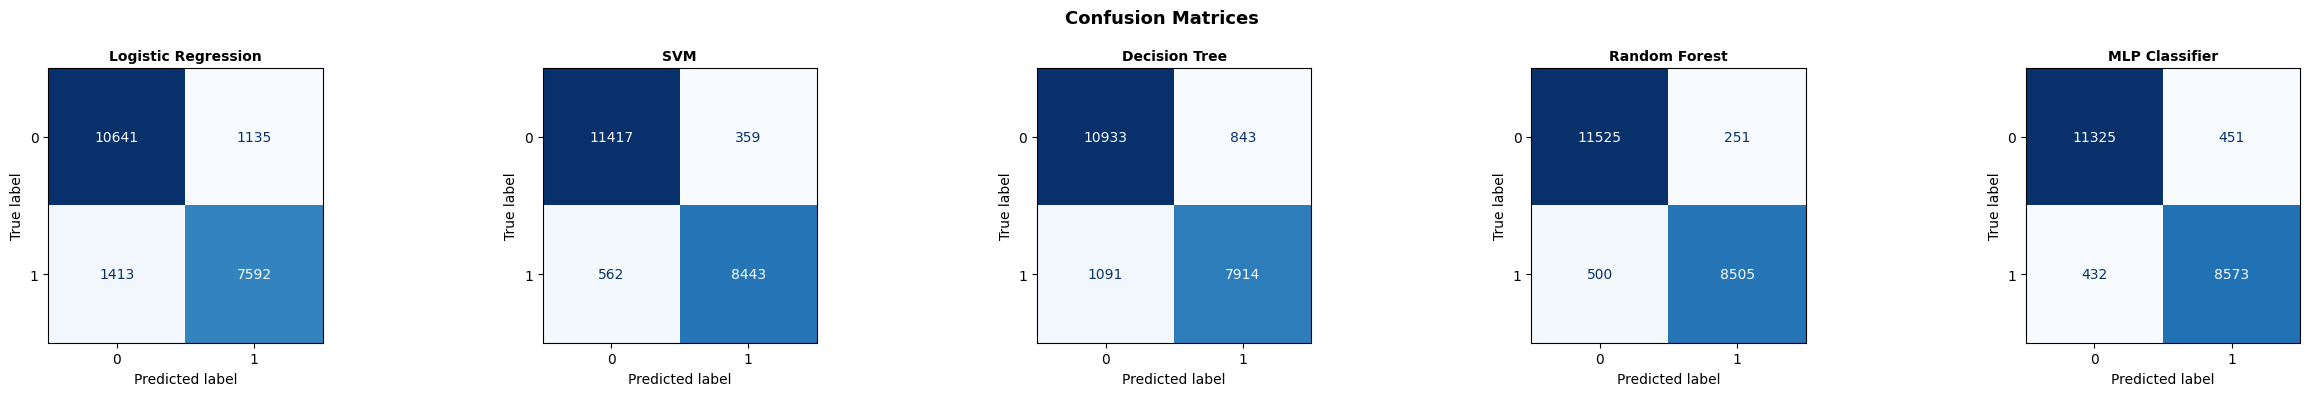

Saved as confusion_matrices.png


In [24]:
def plot_confusion_matrices(reports):
    n = len(reports)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))

    if n == 1:
        axes = [axes]

    for ax, (name, data) in zip(axes, reports.items()):
        disp = ConfusionMatrixDisplay(confusion_matrix=data["cm"])
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(name, fontsize=10, fontweight="bold")

    plt.suptitle("Confusion Matrices", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("confusion_matrices.png", dpi=150)
    plt.show()
    print("Saved as confusion_matrices.png")

plot_confusion_matrices(reports)


##  Accuracy Comparison Chart

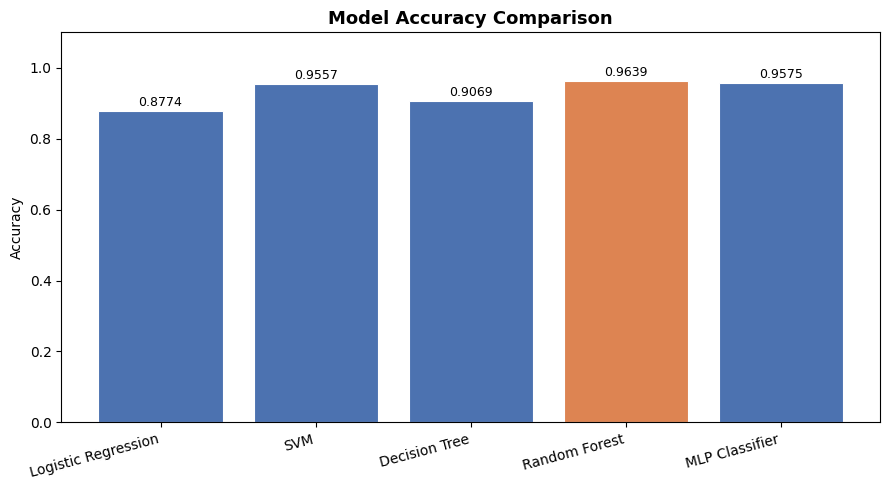

Saved as accuracy_comparison.png


In [25]:
def plot_accuracy_comparison(results):
    names      = list(results.keys())
    accuracies = list(results.values())

    colors   = ["#4C72B0"] * len(names)
    best_idx = accuracies.index(max(accuracies))
    colors[best_idx] = "#DD8452"

    plt.figure(figsize=(9, 5))
    bars = plt.bar(names, accuracies, color=colors, edgecolor="white", linewidth=0.8)

    for bar, acc in zip(bars, accuracies):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{acc:.4f}",
            ha="center", va="bottom", fontsize=9
        )

    plt.title("Model Accuracy Comparison", fontsize=13, fontweight="bold")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.1)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig("accuracy_comparison.png", dpi=150)
    plt.show()
    print("Saved as accuracy_comparison.png")

plot_accuracy_comparison(results)
